<a href="https://colab.research.google.com/github/24tara/Final-Year-Project-Machine-Modelling-of-Credit-Card-Approval-Predictions/blob/main/FYP_DATASET2_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loading

In [210]:
#importing libraries that are relevant, this will allow me to manipulate data and merge tables
#renamed pandas as pd for short
import pandas as pd
import numpy as np
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt

In [211]:
#naming my file as data
#read the csv file
data2= pd.read_csv('/content/final_cleaned_data2.csv')

In [212]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44993 entries, 0 to 44992
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_gender                   44993 non-null  int64  
 2   person_education                44993 non-null  int64  
 3   person_income                   44993 non-null  float64
 4   person_emp_exp                  44993 non-null  float64
 5   person_home_ownership           44993 non-null  int64  
 6   loan_amnt                       44993 non-null  float64
 7   loan_intent                     44993 non-null  int64  
 8   loan_int_rate                   44993 non-null  float64
 9   loan_percent_income             44993 non-null  float64
 10  cb_person_cred_hist_length      44993 non-null  float64
 11  credit_score                    44993 non-null  int64  
 12  previous_loan_defaults_on_file  

In [213]:
# Expand truncated values in pandas data frame
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 100)

In [214]:
data2_sample = data2.sample(frac=0.7, random_state=500)
data2_unseen = data2.drop(data2.index)

data2_sample.reset_index(drop=True, inplace=True)
data2_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data2.shape))
print('Unseen Data For Predictions: ' + str(data2_unseen.shape))

Data for Modeling: (44993, 14)
Unseen Data For Predictions: (0, 14)


In [215]:
data2.columns.tolist()

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status']

In [216]:
#here i am declaring my features and what my target feature is
feature_cols = ['person_age','person_gender','person_education','person_income','person_emp_exp','person_home_ownership','loan_amnt','loan_intent','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','credit_score','previous_loan_defaults_on_file']
X = data2[feature_cols] # Features

y = data2['loan_status'] #target

In [217]:
#this is importing a library from python preparing a model for training data

from sklearn.model_selection import train_test_split

In [218]:
#splitting the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=4, stratify=y)

logistic regression

In [219]:
# importing libraries to help build models
from sklearn.linear_model import LogisticRegression

In [220]:
#choosing a model
logreg = LogisticRegression()

In [221]:
#here i am applying the mdoel to the dataset
# x is the independent variable and y is the target varaible
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [222]:
#this function allows my model to make predictions on the trainnig data
y_pred_train=logreg.predict(X_train)

In [223]:
#this function allows my model to make predictions on the test data
y_pred=logreg.predict(X_test)

In [224]:
#this function allows me to compare my actual data with my predicted data outputs
Comparison_df=pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred})
#this calls the comaprsion results
Comparison_df

,Actual,Predicted
20007,1,0
556,0,0
20729,1,1
7162,0,0
25186,0,0
...,...,...
38240,0,1
33533,0,0
3176,0,0
36351,0,0


In [225]:
#here i am importing relevant libraries to get the accuaray score
from sklearn.metrics import accuracy_score
#i have set the a varaible called accuracy_treain to to get the accuaracy score fo my predctions made from my model
accuracy_train = accuracy_score(y_train, y_pred_train)
#ive called the code to print the accuaracy score
print ("The accuracy is: ", accuracy_train)

The accuracy is:  0.862740117478965


In [226]:
#here i am importing relevant libraries to get the accuaray score
from sklearn.metrics import accuracy_score
#here the is a vairable called accuaracy_test, here i noticed that i had to change the names as the code abode had a varaible called accuarcy
#i changed the code above to _train and this one is _test
accuracy_test = accuracy_score(y_test, y_pred)
#ive called the code to print the accuaracy score
print ("The accuracy is: ", accuracy_test)

The accuracy is:  0.8703511631352793


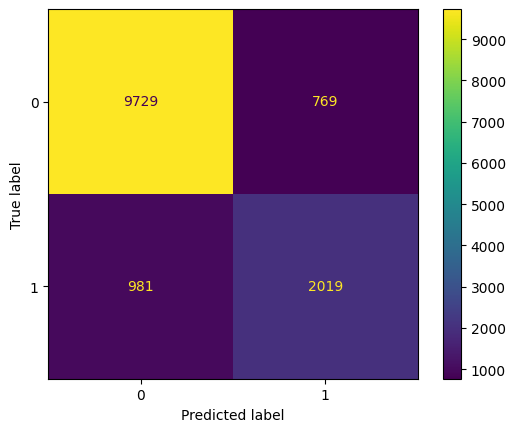

In [227]:
#here i am importing models that i can use from libraries that are relevant, the matrix and the display for it
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#cm is a varaible for the confusion matrix
#i have then mentioned what data i want in the matrix and have said the data will equal to the amount of classes
#i have two classes
cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)
#ive written for it to be plotted
disp.plot()

In [228]:
#importing relavant libraries
from sklearn.metrics import classification_report
#printed the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92     10498
           1       0.72      0.67      0.70      3000

    accuracy                           0.87     13498
   macro avg       0.82      0.80      0.81     13498
weighted avg       0.87      0.87      0.87     13498



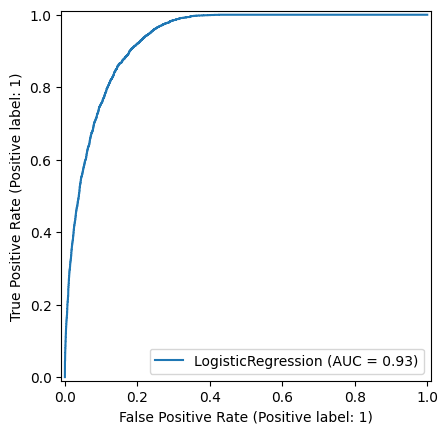

In [229]:
#importing relevant libraires
from sklearn.metrics import RocCurveDisplay
#applying the trest data to another model which is estimating the predictions
#plots
logreg = RocCurveDisplay.from_estimator(logreg, X_test, y_test)

DECISION TREE

In [230]:
#importing relevant libraries
from sklearn.tree import DecisionTreeRegressor

In [231]:
#choosing a model
DT_regressor = DecisionTreeRegressor()
#here i am applying the mdoel to the dataset
# x is the independent variable and y is the target varaible
DT_regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [232]:
#this function allows my model to make predictions on the test data
y_pred = DT_regressor.predict(X_test)

In [233]:
#pulling libraries
from sklearn import metrics
#using different metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

MAE: 0.0982367758186398
MSE: 0.0982367758186398
R2: 0.43169022670984947


In [234]:
#imorioting relevant libraires
from sklearn import tree
from matplotlib import pyplot as plt

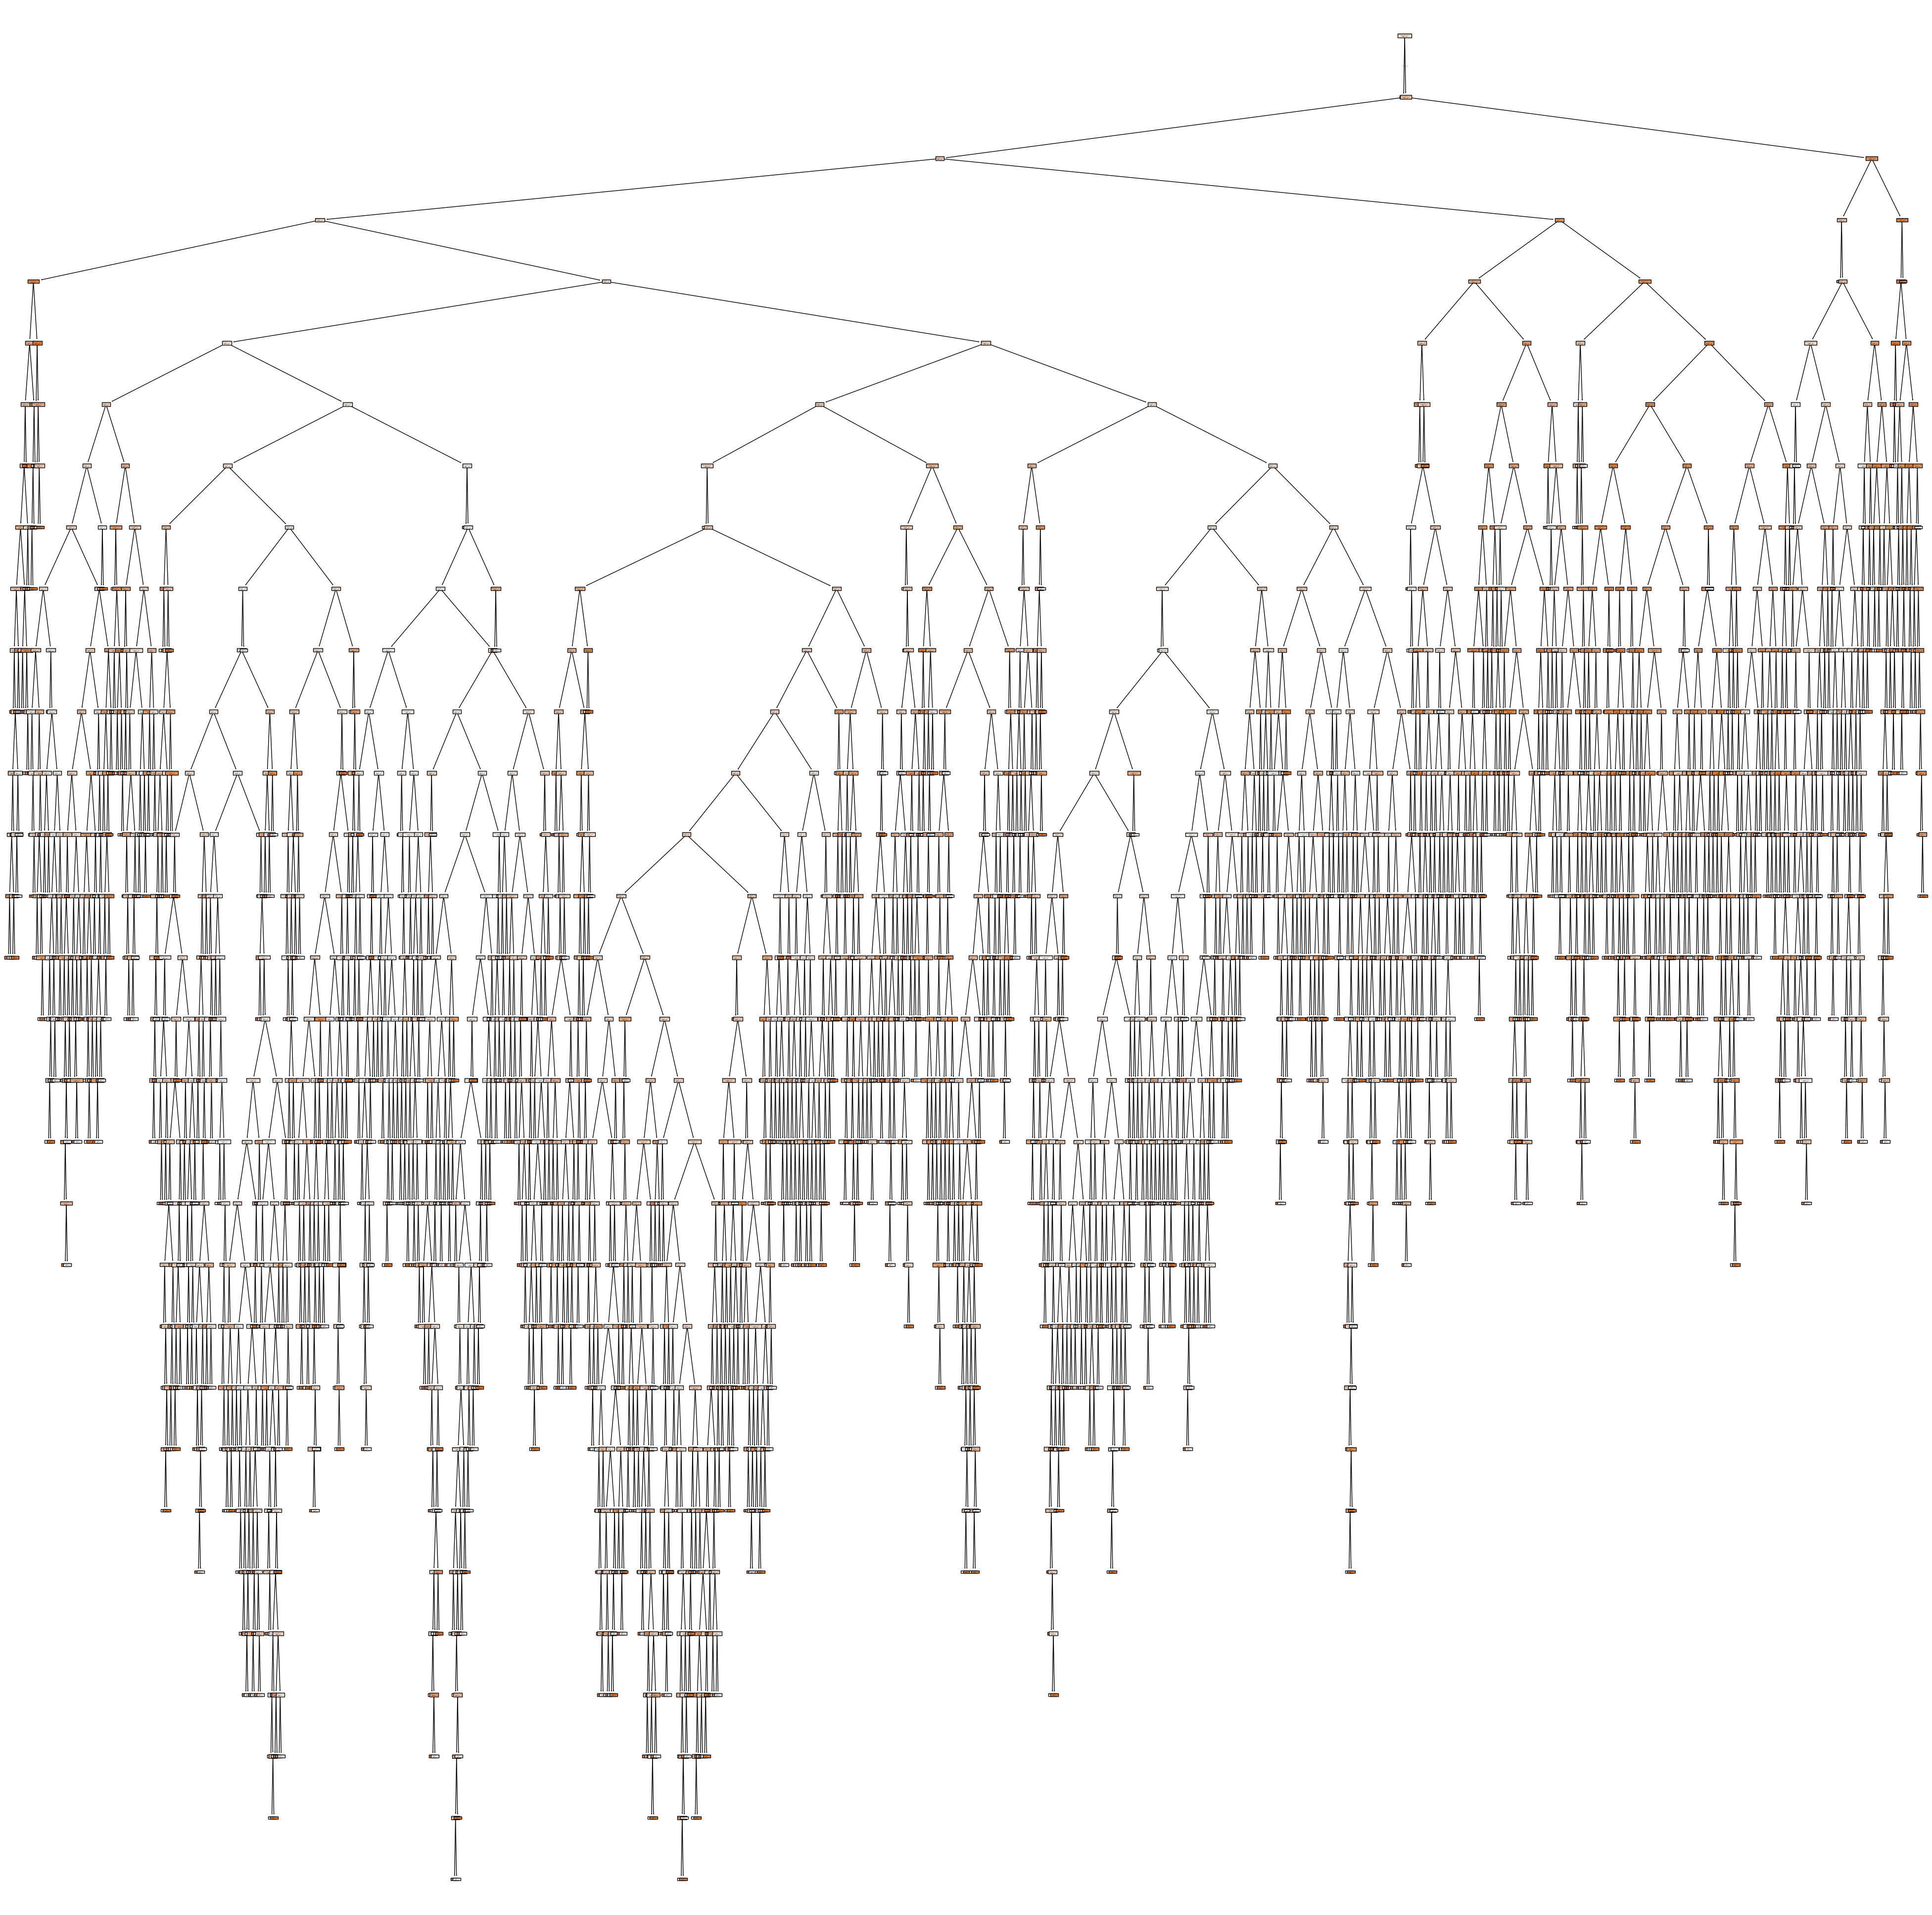

In [235]:
#width and height
Tree_figure = plt.figure(figsize=(50,50))
#plots tree that is trained
DT_Graph = tree.plot_tree(DT_regressor, feature_names=list(X_train.columns), filled=True)

In [236]:
#saves tree
Tree_figure.savefig("decistion_tree.svg")

In [237]:
DT_regressor = DecisionTreeRegressor(max_depth=4)

DT_regressor.fit(X_train, y_train)

y_pred = DT_regressor.predict(X_test)

In [238]:
y_pred

array([0.20470513, 0.        , 0.20470513, ..., 0.        , 0.        ,
       0.20470513])

In [239]:
#import relevant libraries
from sklearn import metrics
#scoring metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))

MAE: 0.13763033304764438
MSE: 0.06953586108578556
R2: 0.5977279474017517


Classification report for DT
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     10498
           1       0.78      0.78      0.78      3000

    accuracy                           0.90     13498
   macro avg       0.86      0.86      0.86     13498
weighted avg       0.90      0.90      0.90     13498

confusion_matrix for DT


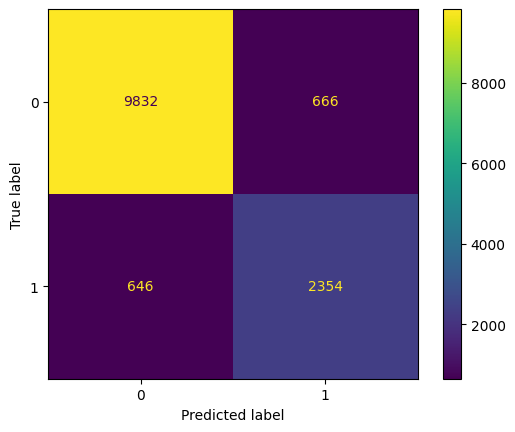

In [240]:
# import the DT algorithm, build the DT model then test it by predicting on the test data
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt=dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

# Evaluate your DT model byt generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for DT")
print(classification_report(y_test,y_pred_dt))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for DT")
dt_cm=confusion_matrix(y_test,y_pred_dt)
disp=ConfusionMatrixDisplay(confusion_matrix=dt_cm,display_labels=dt.classes_)
disp.plot()

RANDOM FOREST


In [ ]:
#create a new random forest classifier and grid search cv
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=13)

#create a dictionary of all values we want to test for n_estimators
params_rf = {'n_estimators': [50, 100, 200]}

#use gridsearch to test all values for n_estimators
rf_gs = GridSearchCV(rf, params_rf, cv=10)

#fit model to training data
rf_gs.fit(X_train, y_train)

#save best model
rf_best = rf_gs.best_estimator_

#check best n_estimators value
print(rf_gs.best_params_)

#make prediction on the test data
y_pred_rf = rf_best.predict(X_test)

# Evaluate your rf model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rf))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rf_cm=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels = rf_best.classes_)
disp.plot()